In [20]:
import os
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import cv2 as cv
import csv
from matplotlib import pyplot as plt
import pandas as pd
from google.colab import drive

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.20.0
Keras version: 3.13.2


In [21]:
########################################################################################################################
# MOUNTING GOOGLE DRIVE
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/VAE_MNIST_Results_Keras'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
########################################################################################################################
# PARAMETERS
########################################################################################################################

latent_dim = 2

batch_size = 512

init_lr = 1e-3
reduce_lr = 10
reduce_lr_cooldown = 5
early_stopping = 3 * (reduce_lr + reduce_lr_cooldown)
max_epochs = 1000

vae_path = os.path.join(drive_results_folder, f'trained_vae_{latent_dim}d.weights.h5')
training_log_path = os.path.join(drive_results_folder, f'training_log_{latent_dim}d.csv')
training_loss_path = os.path.join(drive_results_folder, f'training_loss_{latent_dim}d.png')
features_path = os.path.join(drive_results_folder, f'features_{latent_dim}d.csv')
features_scatter_path = os.path.join(drive_results_folder, f'features_{latent_dim}d_scatter.png')
visualization_path = os.path.join(drive_results_folder, f'visualization_{latent_dim}d.png')

In [28]:
########################################################################################################################
# LOADING AND PROCESSING DATASET
########################################################################################################################

# Loading MNIST dataset
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

# Concatenating validation set to train set
x_train = np.concatenate((x_train, x_val))
y_train = np.concatenate((y_train, y_val))
x_val, y_val = None, None

# Display some statistics
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

# Add 3rd dimension to images
x_train = np.expand_dims(x_train, axis=-1)
print(x_train.shape)

# Define image size parameter
image_size = x_train.shape[1:]
print(image_size)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
{0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}
(70000, 28, 28, 1)
(28, 28, 1)


In [24]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

# Encoder
def build_encoder(inputs):
    y = inputs / 255

    y1 = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)
    y = tf.keras.layers.MaxPool2D()(y)

    y1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)
    y = tf.keras.layers.MaxPool2D()(y)

    y1 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)

    y = tf.keras.layers.GlobalAveragePooling2D()(y)
    return y


# Decoder
def build_decoder(latent_inputs):
    y = tf.keras.layers.Dense(7*7*128, activation='relu')(latent_inputs)
    y = tf.keras.layers.Reshape(target_shape=(7, 7, 128))(y)

    y1 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)
    y = tf.keras.layers.UpSampling2D(size=(2, 2))(y)

    y1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)
    y = tf.keras.layers.UpSampling2D(size=(2, 2))(y)

    y1 = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(y)
    y1 = tf.keras.layers.BatchNormalization()(y1)
    y1 = tf.keras.layers.Activation(activation='relu')(y1)
    y2 = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(y1)
    y2 = tf.keras.layers.BatchNormalization()(y2)
    y = tf.keras.layers.add(inputs=[y1, y2])
    y = tf.keras.layers.Activation(activation='relu')(y)
    y = 255 * tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')(y)
    return y


# Reparameterization trick
# instead of sampling from Q(z|X), sample epsilon = N(0,I)
# z = z_mean + sqrt(var) * epsilon
def sampling(args):
    """ Reparameterization trick by sampling from an isotropic unit Gaussian.
    # Arguments
        args (tensor): mean and log of variance of Q(z|X)
    # Returns
        z (tensor): sampled latent vector
    """
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    # by default, tf.random.normal has mean = 0.0 and stddev = 1.0
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_model(weights_file=None):
    inputs = tf.keras.Input(shape=image_size, name='encoder_input')

    # instantiate encoder
    y = build_encoder(inputs)

    # build encoder model
    z_mean = tf.keras.layers.Dense(latent_dim, name='z_mean')(y)
    z_log_var = tf.keras.layers.Dense(latent_dim, name='z_log_var')(y)

    # use reparameterization trick to push the sampling out as input
    z = tf.keras.layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

    # instantiate encoder model
    encoder = tf.keras.models.Model(inputs, [z_mean, z_log_var, z], name='encoder')

    # build decoder model
    latent_inputs = tf.keras.layers.Input(shape=(latent_dim,), name='z_sampling')
    decoder_outputs = build_decoder(latent_inputs)

    # instantiate decoder model
    decoder = tf.keras.models.Model(latent_inputs, decoder_outputs, name='decoder')

    # get VAE output
    outputs = decoder(encoder(inputs)[2])

    # ------- Wrap the loss calculation in a Custom Layer -------
    class VAELossLayer(tf.keras.layers.Layer):
        def call(self, inputs, outputs, z_mean, z_log_var):
            y_true = inputs / 255.0
            y_pred = outputs / 255.0

            reconstruction_loss = tf.square(y_pred - y_true)
            kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)

            reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=[1, 2, 3])
            kl_loss = tf.reduce_sum(kl_loss, axis=1)

            loss = tf.reduce_mean(reconstruction_loss - 0.5 * kl_loss)
            self.add_loss(loss)
            return outputs

    # Pass the tensors through the loss layer
    outputs = VAELossLayer()(inputs, outputs, z_mean, z_log_var)
    # ----------------------------------------------------------

    # instantiate VAE model
    vae = tf.keras.models.Model(inputs, outputs, name='vae')

    if weights_file is not None:
        vae.load_weights(weights_file)

    return vae, encoder, decoder

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_8       │ (None, 28, 28, 1) │          0 │ encoder_input[0]… │
│ (TrueDivide)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 28, 28,    │        320 │ true_divide_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 28, 28,    │      9,248 │ activation_48[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 28, 28,    │          0 │ activation_48[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_49       │ (None, 28, 28,    │          0 │ add_24[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ activation_49[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_50       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 14, 14,    │     36,928 │ activation_50[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 14, 14,    │          0 │ activation_50[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_51       │ (None, 14, 14,    │          0 │ add_25[0][0]    

 Total params: 288,740 (1.10 MB)

 Trainable params: 287,844 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_8       │ (None, 28, 28, 1) │          0 │ encoder_input[0]… │
│ (TrueDivide)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 28, 28,    │        320 │ true_divide_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 28, 28,    │      9,248 │ activation_48[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 28, 28,    │          0 │ activation_48[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_49       │ (None, 28, 28,    │          0 │ add_24[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ activation_49[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_50       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 14, 14,    │     36,928 │ activation_50[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 14, 14,    │          0 │ activation_50[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_51       │ (None, 14, 14,    │          0 │ add_25[0][0]    

 Total params: 743,237 (2.84 MB)

 Trainable params: 741,445 (2.83 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/1000

Epoch 1: loss improved from None to 46.34848, saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5
137/137 - 58s - 424ms/step - loss: 46.3485 - learning_rate: 0.0010
Epoch 2/1000

Epoch 2: loss improved from 46.34848 to 39.77172, saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5
137/137 - 20s - 146ms/step - loss: 39.7717 - learning_rate: 0.0010
Epoch 3/1000

Epoch 3: loss improved from 39.77172 to 38.83080, saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/VAE_MNIST_Results_Keras/trained_vae_2d.weights.h5
137/137 - 20s - 148ms/step - loss: 38.8308 - learning_rate: 0.0010
Epoch 4/1000

Epoch 

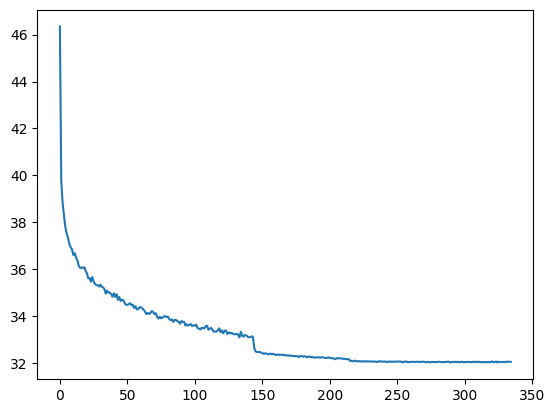

In [25]:
########################################################################################################################
# TRAIN MODEL
########################################################################################################################

# CREATE MODEL
vae, encoder, decoder = build_model()

vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=init_lr))

encoder.summary()
decoder.summary()
vae.summary()

# CALLBACKS
checkpointer = tf.keras.callbacks.ModelCheckpoint(filepath=vae_path, verbose=1, save_best_only=True,
                                                  save_weights_only=True, monitor='loss', mode='min')

csv_logger = tf.keras.callbacks.CSVLogger(training_log_path, separator=',', append=False)

early_stopping = tf.keras.callbacks.EarlyStopping(patience=early_stopping, verbose=1, restore_best_weights=True,
                                                  monitor='loss', mode='min')

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=reduce_lr, cooldown=reduce_lr_cooldown,
                                                 verbose=1, monitor='loss', mode='min')

# TRAINING
hist = vae.fit(x=x_train, y=None,
               batch_size=batch_size,
               epochs=max_epochs,
               validation_data=None,
               shuffle=True,
               callbacks=[csv_logger, checkpointer, early_stopping, reduce_lr],
               verbose=2)

vae.save_weights(vae_path)

plt.clf()
plt.plot(hist.history['loss'])
plt.savefig(training_loss_path)
plt.show()

Extracting features
.........................................................................................................................................


<Figure size 640x480 with 0 Axes>

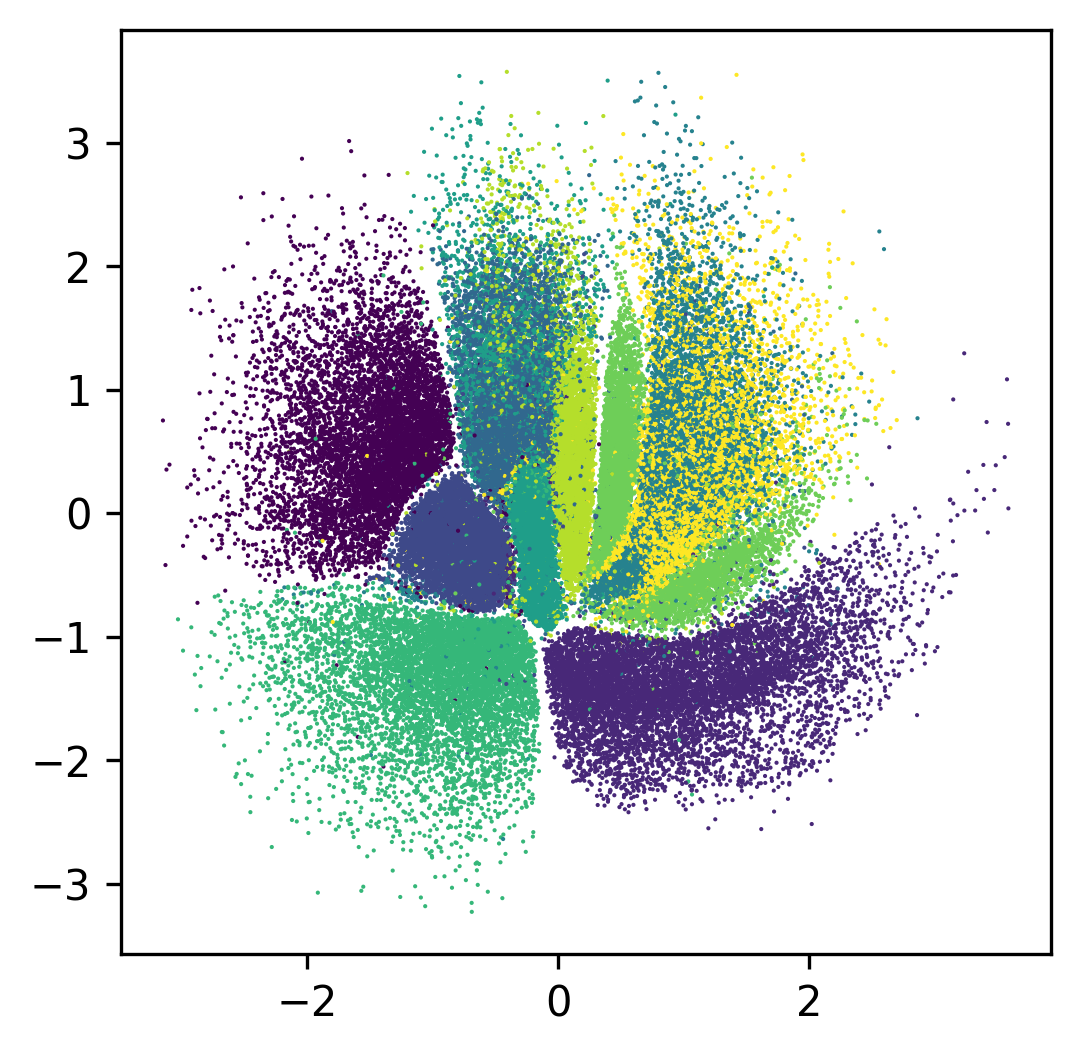

zx_min = -3.1510508 , zx_max = 3.5853336
zy_min = -3.2289112 , zy_max = 3.574381
Generating images
........................................


<Figure size 640x480 with 0 Axes>

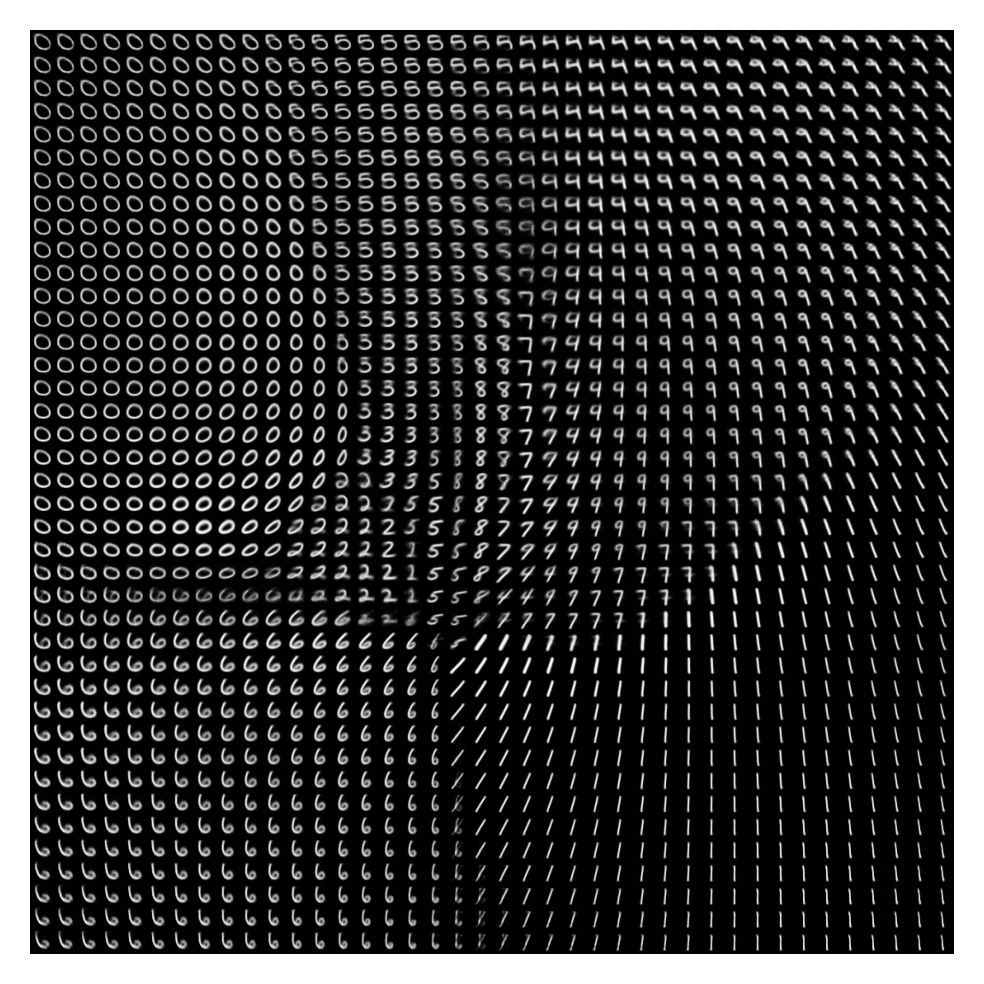

In [31]:
########################################################################################################################
# EVALUATE
########################################################################################################################

# LOAD MODEL
vae, encoder, decoder = build_model(weights_file=vae_path)

# EXTRACT FEATURES USING VAE ENCODER
print('Extracting features')
header = ['digit'] + ['f{}'.format(i+1) for i in range(latent_dim)]
flist = [header]
z_train = np.zeros((len(x_train), latent_dim), dtype=np.float32)
for i in range(0, len(x_train), batch_size):
    x = x_train[i:i+batch_size]
    z_train[i:i+batch_size] = encoder.predict(x, verbose=0)[0]
    for j in range(len(x)):
        f = [y_train[i+j]] + [v for v in z_train[i+j]]
        flist.append(f)
    print('.', end='')
print()

# Save features to CSV
with open(features_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(flist)

# Visualize 2D feature using scatter plot
if latent_dim == 2:
    features_df = pd.read_csv(features_path)
    plt.clf()
    plt.figure(figsize=(4, 4), dpi=300)
    plt.scatter(features_df['f1'], features_df['f2'], c=features_df['digit'], cmap='viridis', s=1, linewidths=0)
    plt.savefig(features_scatter_path)
    plt.show()


# GENERATE GRID OF IMAGES WITH VAE DECODER BY SAMPLING Z
if latent_dim == 2:
    # Number of steps
    n = 40

    # Range of latent variables
    zx_min = np.min(z_train[:, 0])
    zx_max = np.max(z_train[:, 0])
    print('zx_min =', zx_min, ', zx_max =', zx_max)
    zy_min = np.min(z_train[:, 1])
    zy_max = np.max(z_train[:, 1])
    print('zy_min =', zy_min, ', zy_max =', zy_max)

    print('Generating images')
    img = np.zeros((n * image_size[0], n * image_size[1]), dtype=np.uint8)
    for i in range(n):
        for j in range(n):
            # Generate latent vector z
            x = zx_min + j * (zx_max-zx_min) / (n-1)
            y = zy_min + (n-1-i) * (zy_max-zy_min) / (n-1)
            z = np.array([[x, y]])
            # Generate decoder output based on latent vector z
            y = decoder.predict(z, verbose=0)
            # Convert output into image
            img_patch = np.clip(np.round(y[0, :, :, 0]), a_min=0, a_max=255).astype(np.uint8)
            # Copy image into image grid
            img[i*image_size[0]:(i+1)*image_size[0], j*image_size[1]:(j+1)*image_size[1]] = img_patch.copy()
        print('.', end='')
    print()

    # Save image grid
    cv.imwrite(visualization_path, img)
    plt.clf()
    plt.figure(figsize=(4, 4), dpi=300)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()